# Classification: Drug Consumption Dataset
 
**Dataset:** Drug Consumption (UCI Machine Learning Repository)  
**Author:** *Daniel Marquino Pérez*

---

## 1. Dataset Description and Classification Context

The *Drug Consumption* dataset contains **1,884 respondents** described by 31 features: 5 demographic variables, 7 personality scores (z-scaled), and 19 drug-consumption columns on the ordinal scale CL0-CL6.

Building on the exploratory data analysis, this notebook addresses the central research question raised there: *can personality traits and demographic characteristics predict Cannabis consumption?* The EDA suggested a preliminary association between Sensation Seeking, Openness, younger age groups, and recent Cannabis use. This classification phase formalises this hypothesis into a predictive task and quantifies how well the relationship holds.

**Classification task.** Binary classification of respondents into *Cannabis users* (any reported use, CL1-CL6) versus *non-users* (CL0). Rationale for binarisation: Cannabis is an ordinal feature, so arithmetic on the CL labels is not meaningful. A binary split at the CL0 boundary produces interpretable classes and avoids the small-sample problem of the upper CL levels.

**Classifiers compared.** Decision Tree and k-Nearest Neighbour. These represent two distinct perspectives on the dataset and offer a clear contrast.

**Validation.** Stratified 5-fold cross-validation, reporting both accuracy and F1-score because the target classes are moderately imbalanced.

---
## 2. Setup: Import Packages

In [2]:
# Import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   # Graphics package
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sklearn.metrics as skm

# Load dataset directly from github URL
URL = 'https://raw.githubusercontent.com/maarqui/drug-consumption-analysis/main/Drug_Consumption.csv'
myData = pd.read_csv(URL)

# Remove the ID column - it is a row identifier with no analytical value
myData = myData.drop(columns=['ID'])

print('Dataset loaded: %d rows x %d columns' % myData.shape)

Dataset loaded: 1884 rows x 31 columns


In [ ]:
demographic_nominal = ['Gender', 'Country', 'Ethnicity']
demographic_ordinal = ['Age', 'Education']
personality_scores  = ['Nscore', 'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS']

print('Personality scores (n=%d):' % len(personality_scores), personality_scores)
print('Demographic nominal      :', demographic_nominal)
print('Demographic ordinal      :', demographic_ordinal)

Personality scores (n=7): ['Nscore', 'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS']
Demographic nominal      : ['Gender', 'Country', 'Ethnicity']
Demographic ordinal      : ['Age', 'Education']


---
## 3. Target Variable Definition

The target variable is constructed by binarising Cannabis based on the CL0 boundary:

- **Class 0 - Non-user**: respondents reporting `CL0` (never used Cannabis).
- **Class 1 - User**: respondents reporting any of `CL1`-`CL6` (used at least once).

This choice has three justifications: 
- ordinal labels `CL1`-`CL6` cannot be averaged meaningfully, so binarisation produces a target that respects the measurement scale. 
- the `CL0` boundary is the only one that always separates the population into two meaningfull groups, divisions in finer splits like recent use leave a more uneaven distribution. 
- the binary form connects directly with the hypothesis reached in the EDA about personality and substance exposure.

In [4]:
# Create binary target: 1 = user (CL1-CL6) | 0 = non-user (CL0)
myData['Cannabis_user'] = (myData['Cannabis'] != 'CL0').astype(int)

# Frequency table for the target
tab_target = myData['Cannabis_user'].value_counts().sort_index()
n_total = len(myData)

print('Class distribution for Cannabis users:')
print('  Non-user (0): %4d (%.1f%%)' % (tab_target[0], 100 * tab_target[0] / n_total))
print('  User    (1): %4d (%.1f%%)' % (tab_target[1], 100 * tab_target[1] / n_total))

Class distribution for Cannabis users:
  Non-user (0):  412 (21.9%)
  User    (1): 1472 (78.1%)


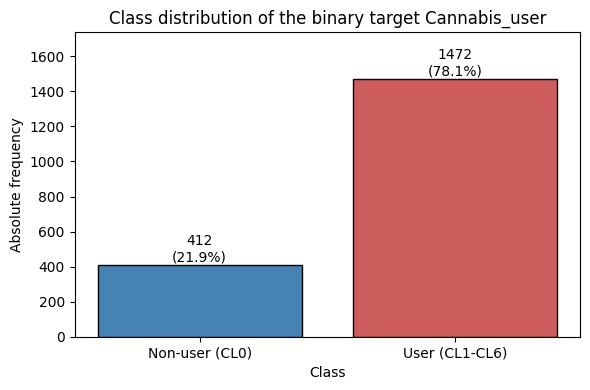

In [5]:
# Bar chart representation of class balance
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['steelblue', 'indianred']
bars = ax.bar(['Non-user (CL0)', 'User (CL1-CL6)'], tab_target.values, color=colors, edgecolor='black')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            '%d\n(%.1f%%)' % (bar.get_height(), 100 * bar.get_height() / n_total),
            ha='center', fontsize=10)

ax.set_title('Class distribution of the binary target Cannabis_user')
ax.set_xlabel('Class')
ax.set_ylabel('Absolute frequency')
ax.set_ylim(0, tab_target.max() * 1.18)
plt.tight_layout()

The class split is approximately **76% users / 24% non-users**.

---
## 4. Feature Selection and Preprocessing

**Predictors used:** the 7 personality scores plus the 5 demographic features (Age, Gender, Education, Country, Ethnicity).

**Variables explicitly excluded:**

- **All drug columns** as using them would introduce data leakage(the model would learn the trivial co-occurrence of substance use).
- **Semer** (ficticious validity-check substance).
- **Cannabis** as it is used to derive the target.

**Encoding of features:** ordinal integers for Age and Education, one-hot dummies for nominal Gender/Country/Ethnicity, z-scores for personality.

In [6]:
# Ordinal mapping for Age (youngest -> oldest)
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_mapping = {label: i for i, label in enumerate(age_order)}
myData['Age_ord'] = myData['Age'].map(age_mapping)

# Ordinal mapping for Education
education_order = [
    'Left school before 16 years',
    'Left school at 16 years',
    'Left school at 17 years',
    'Left school at 18 years',
    'Some college or university, no certificate or degree',
    'Professional certificate/ diploma',
    'University degree',
    'Masters degree',
    'Doctorate degree',
]
education_mapping = {label: i for i, label in enumerate(education_order)}
myData['Education_ord'] = myData['Education'].map(education_mapping)

# One-hot encoding for the nominal demographic features
one_hot_nominal = pd.get_dummies(myData[demographic_nominal], drop_first=False, dtype=int)

# Final feature matrix and target vector
X = pd.concat([
    myData[personality_scores].reset_index(drop=True),
    myData[['Age_ord', 'Education_ord']].reset_index(drop=True),
    one_hot_nominal.reset_index(drop=True),
], axis=1)
y = myData['Cannabis_user'].values

# Scaled copy for kNN (Min-Max to [0,1])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print('Age_ord missing       : %d' % myData['Age_ord'].isna().sum())
print('Education_ord missing : %d' % myData['Education_ord'].isna().sum())
print('Feature matrix X      : %d rows x %d columns' % X.shape)
print('Target vector y       : %d entries' % len(y))

Age_ord missing       : 0
Education_ord missing : 0
Feature matrix X      : 1884 rows x 25 columns
Target vector y       : 1884 entries


**Scaling for kNN.** Personality scores have range ~[−3, 3] while one-hot dummies are 0/1. If not re-scaled, the personality features would be more dominant. A scaled copy of X is prepared here for kNN, the Decision Tree does not require scaling.

---
## 5. Cross-Validation Setup

cross-validation is defined as the partitioning of the data into N disjoint folds. With n = 1,884 observations, k = 5 is appropriate (convention for datasets with this scale).

`StratifiedKFold` is preferred over plain `KFold` because the target classes are imbalanced (76/24). Stratification preserves the class proportion in each fold and avoids uneven splits.

In [7]:
# Stratified 5-fold cross-validation strategy
N = 5
cv = StratifiedKFold(n_splits=N, shuffle=True, random_state=42)

print('Cross-validation strategy : %s' % type(cv).__name__)
print('Number of folds           : %d' % cv.get_n_splits())

Cross-validation strategy : StratifiedKFold
Number of folds           : 5


## 5.2 Helper Functions

The five operations that follow (hyperparameter tuning, CV-curve plot, final evaluation, confusion matrix, importance bar chart) are applied identically to both the Decision Tree and kNN. To avoid duplicated code blocks, they are defined once here as functions and invoked in Sections 6, 7 and 9. The numerical results are unchanged because each function reproduces the same `cross_val_score` / `cross_val_predict` calls used previously.

In [1]:
def tune_hyperparameter(make_model, param_values, X_data, y_data, cv, scoring='f1_weighted'):
    '''
    Tune a single hyperparameter via cross-validation.
    make_model: callable that takes one parameter value and returns an estimator.
    Returns: list of mean CV scores.
    '''
    scores_per_value = []
    for value in param_values:
        model = make_model(value)
        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring=scoring)
        scores_per_value.append(scores.mean())
    return scores_per_value


def plot_cv_curve(param_values, scores, best_value, xlabel, title, color, log_x=False):
    '''Plot mean CV F1 as a function of a hyperparameter, marking the best value.'''
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(param_values, scores, marker='o', color=color, linewidth=2)
    ax.axvline(best_value, color='firebrick', linestyle='--', linewidth=1,
               label='Best %s = %s' % (xlabel, str(best_value)))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean weighted F1-score')
    if log_x:
        ax.set_xscale('log')
        ax.set_xticks(param_values)
        ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
    else:
        ax.set_xticks(param_values)
    ax.legend()
    plt.tight_layout()


def evaluate_final(model, X_data, y_data, cv, name):
    '''Run final 5-fold CV and print accuracy and weighted F1 (mean +/- std).'''
    acc = cross_val_score(model, X_data, y_data, cv=cv, scoring='accuracy')
    f1  = cross_val_score(model, X_data, y_data, cv=cv, scoring='f1_weighted')
    print('%s, 5-fold CV:' % name)
    print('  Accuracy        : %.4f ± %.4f' % (acc.mean(), acc.std()))
    print('  Weighted F1     : %.4f ± %.4f' % (f1.mean(),  f1.std()))
    return acc, f1


def plot_confusion_cv(model, X_data, y_data, cv, cmap, title):
    '''
    Produce an out-of-fold confusion matrix from CV predictions and display it.
    Also prints sensitivity and specificity from the matrix.
    '''
    predicted = cross_val_predict(model, X_data, y_data, cv=cv)
    cm = confusion_matrix(y_data, predicted)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-user', 'User'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()

    tn, fp, fn, tp = cm.ravel()
    print('True negatives  : %d   False positives : %d' % (tn, fp))
    print('False negatives : %d   True positives  : %d' % (fn, tp))
    print('Sensitivity (Recall positive) : %.4f' % (tp / (tp + fn)))
    print('Specificity (Recall negative) : %.4f' % (tn / (tn + fp)))
    return predicted, cm


def plot_importance_bars(feature_names, importance_values, title, xlabel, cmap_name):
    '''Sort and plot a horizontal bar chart of feature importance.'''
    pairs = sorted(zip(feature_names, importance_values), key=lambda t: t[1])
    names_sorted  = [t[0] for t in pairs]
    values_sorted = [t[1] for t in pairs]

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.15, 0.95, len(names_sorted)))
    ax.barh(names_sorted, values_sorted, color=colors, edgecolor='black')
    ax.axvline(0, color='gray', linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Feature')
    plt.tight_layout()


print('Helper functions defined: tune_hyperparameter, plot_cv_curve, evaluate_final, plot_confusion_cv, plot_importance_bars')

Helper functions defined: tune_hyperparameter, plot_cv_curve, evaluate_final, plot_confusion_cv, plot_importance_bars


---
## 6. Classifier 1: Decision Tree

The Decision Tree is selected as the first classifier:

1. **Interpretability**: the tree can be read as a sequence of decision rules.
2. **No scaling required**: tree splits are invariant under monotonic transformations.

The split criterion is `entropy`. `max_depth` is tuned by cross-validation.

In [12]:
# Adjust max_depth via 5-fold cross-validation
from sklearn import tree

depths = list(range(2, 16))
make_tree = lambda d: tree.DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
scores_tree = tune_hyperparameter(make_tree, depths, X, y, cv)
best_depth = depths[int(np.argmax(scores_tree))]
print('\nBest max_depth : %d' % best_depth)
print('Best mean F1   : %.4f' % max(scores_tree))


Best max_depth : 8
Best mean F1   : 0.7697


Decision Tree (max_depth=8), 5-fold CV:
  Accuracy        : 0.7712 ± 0.0155
  Weighted F1     : 0.7697 ± 0.0133


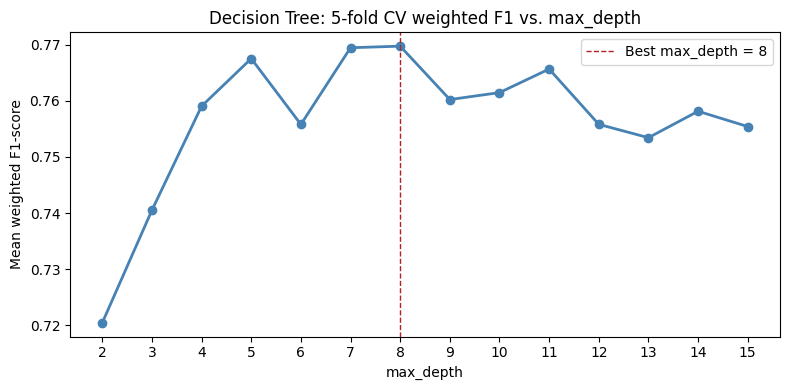

In [13]:
# CV curve and final evaluation
plot_cv_curve(depths, scores_tree, best_depth,
              xlabel='max_depth',
              title='Decision Tree: 5-fold CV weighted F1 vs. max_depth',
              color='steelblue')

dectree = make_tree(best_depth)
acc_tree, f1_tree = evaluate_final(dectree, X, y, cv, 'Decision Tree (max_depth=%d)' % best_depth)

True negatives  : 194   False positives : 218
False negatives : 213   True positives  : 1259
Sensitivity (Recall positive) : 0.8553
Specificity (Recall negative) : 0.4709


```
              precision    recall  f1-score   support

    Non-user       0.48      0.47      0.47       412
        User       0.85      0.86      0.85      1472

    accuracy                           0.77      1884
   macro avg       0.66      0.66      0.66      1884
weighted avg       0.77      0.77      0.77      1884

```

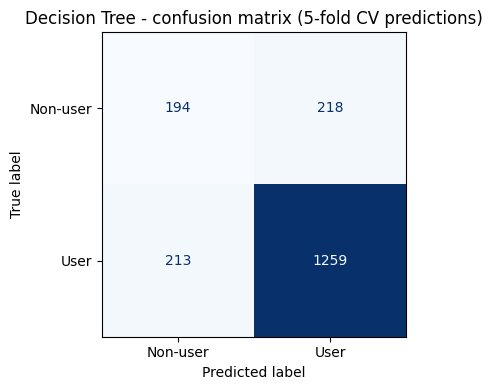

In [14]:
# Confusion matrix from out-of-fold predictions
Predicted_tree, cm_tree = plot_confusion_cv(
    dectree, X, y, cv,
    cmap='Blues',
    title='Decision Tree - confusion matrix (5-fold CV predictions)')

# Classification report
from IPython.display import display, Markdown
report = classification_report(y, Predicted_tree, target_names=['Non-user', 'User'])
display(Markdown('```\n' + report + '\n```'))

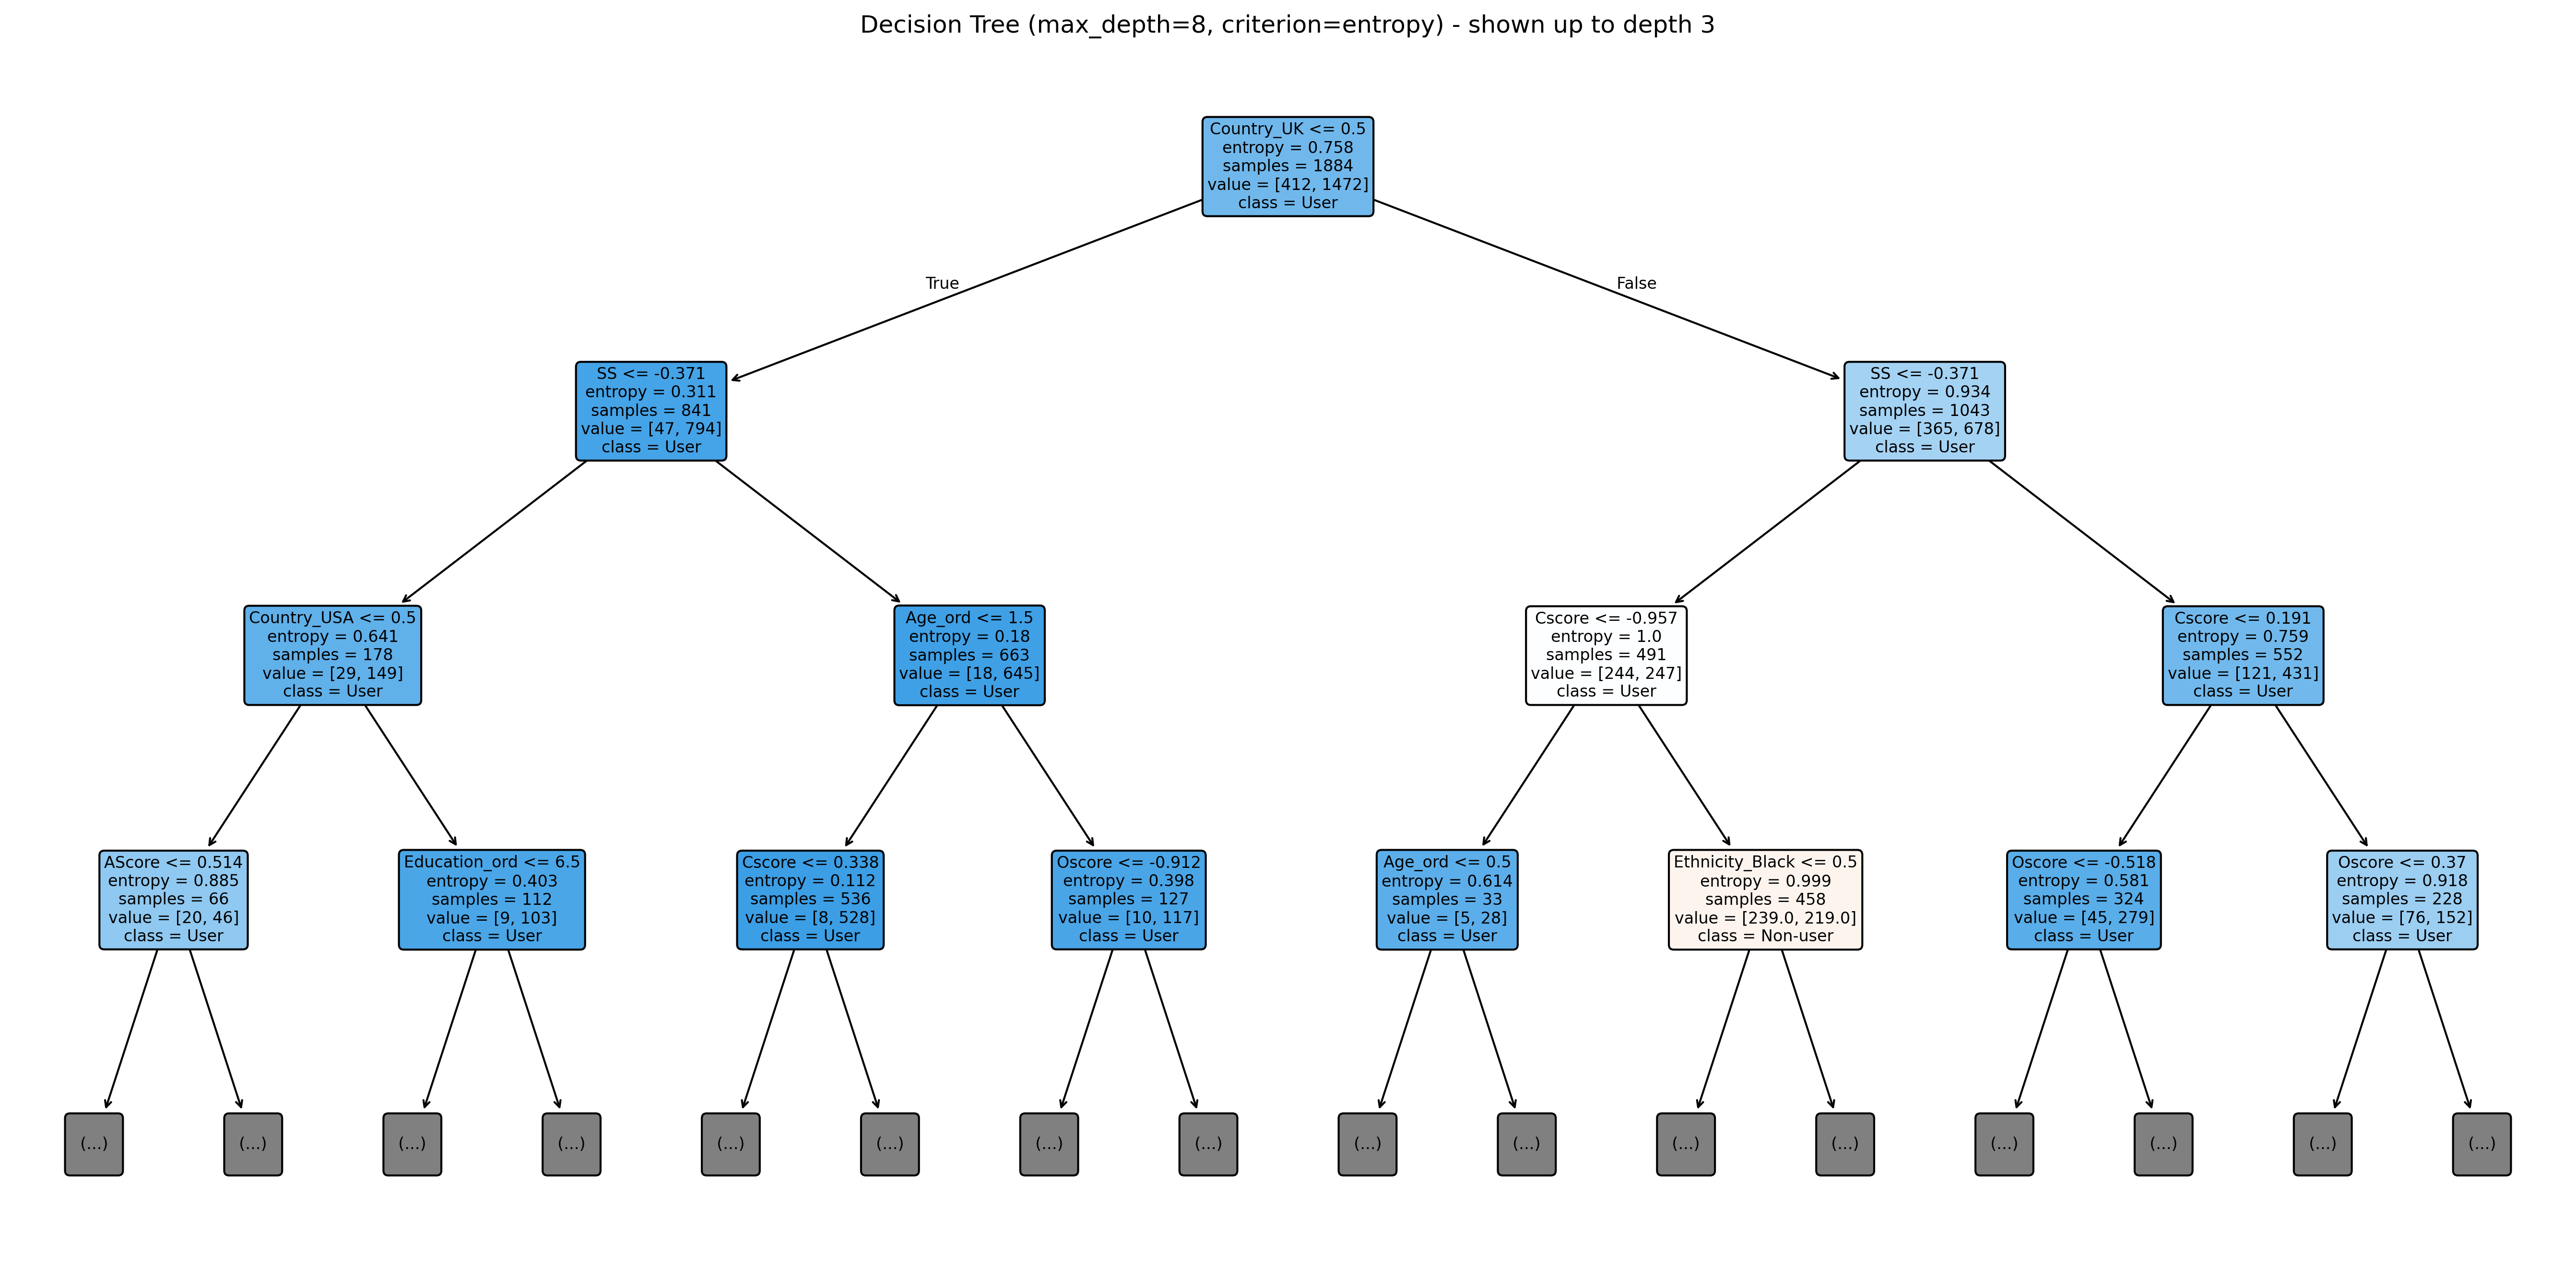

In [21]:
# Fit the final tree on the full data and plot it
dectree.fit(X, y)

plt.figure(dpi=300, figsize=(18, 9))
tree.plot_tree(dectree, max_depth=3,
               feature_names=list(X.columns),
               class_names=['Non-user', 'User'],
               filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (max_depth=%d, criterion=entropy) - shown up to depth 3' % best_depth)
plt.tight_layout()

---
## 7. Classifier 2: k-Nearest Neighbour

The kNN classifier provides a contrasting paradigm: instance-based learning where classification is performed by comparing each query point to the stored training set. The algorithm depends entirely on the feature-space geometry, which makes scaling essential.

The pre-scaled feature matrix `X_scaled` (from Section 4) is used, the number of neighbours `k` is tuned over odd values to avoid ties in the binary problem and the distance metric is Euclidean (default).

In [15]:
# Adjust k using 5-fold cross-validation
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
make_knn = lambda k: KNeighborsClassifier(n_neighbors=k, metric='euclidean')

scores_knn = tune_hyperparameter(make_knn, k_values, X_scaled, y, cv)
best_k     = k_values[int(np.argmax(scores_knn))]

print('Best k        : %d' % best_k)
print('Best mean F1  : %.4f' % max(scores_knn))

Best k        : 7
Best mean F1  : 0.7935


kNN (k=7, Euclidean), 5-fold CV:
  Accuracy        : 0.8041 ± 0.0123
  Weighted F1     : 0.7935 ± 0.0143


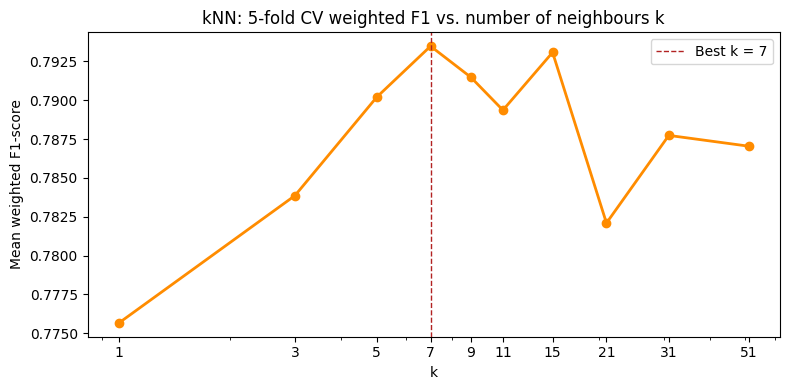

In [16]:
# CV curve and final evaluation
plot_cv_curve(k_values, scores_knn, best_k,
              xlabel='k',
              title='kNN: 5-fold CV weighted F1 vs. number of neighbours k',
              color='darkorange',
              log_x=True)

knn = make_knn(best_k)
acc_knn, f1_knn = evaluate_final(knn, X_scaled, y, cv, 'kNN (k=%d, Euclidean)' % best_k)

True negatives  : 177   False positives : 235
False negatives : 134   True positives  : 1338
Sensitivity (Recall positive) : 0.9090
Specificity (Recall negative) : 0.4296


```
              precision    recall  f1-score   support

    Non-user       0.57      0.43      0.49       412
        User       0.85      0.91      0.88      1472

    accuracy                           0.80      1884
   macro avg       0.71      0.67      0.68      1884
weighted avg       0.79      0.80      0.79      1884

```

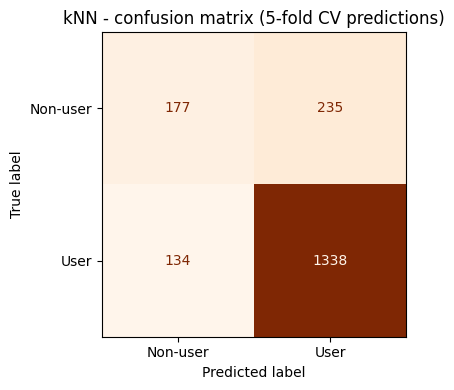

In [17]:
# Confusion matrix from out-of-fold predictions
Predicted_knn, cm_knn = plot_confusion_cv(
    knn, X_scaled, y, cv,
    cmap='Oranges',
    title='kNN - confusion matrix (5-fold CV predictions)')

# Classification report
report = classification_report(y, Predicted_knn, target_names=['Non-user', 'User'])
display(Markdown('```\n' + report + '\n```'))

---
## 8. Model Comparison

Side-by-side comparison of the two classifiers:

In [18]:
# Summary comparison table
print('5-fold cross-validation results:')
print()
print('%-30s %-18s %-18s' % ('Classifier', 'Accuracy', 'Weighted F1'))
print('-' * 66)
print('%-30s %.4f ± %.4f    %.4f ± %.4f' %
      ('Decision Tree (depth=%d)' % best_depth,
       acc_tree.mean(), acc_tree.std(),
       f1_tree.mean(),  f1_tree.std()))
print('%-30s %.4f ± %.4f    %.4f ± %.4f' %
      ('kNN (k=%d)' % best_k,
       acc_knn.mean(), acc_knn.std(),
       f1_knn.mean(),  f1_knn.std()))

5-fold cross-validation results:

Classifier                     Accuracy           Weighted F1       
------------------------------------------------------------------
Decision Tree (depth=8)        0.7712 ± 0.0155    0.7697 ± 0.0133
kNN (k=7)                      0.8041 ± 0.0123    0.7935 ± 0.0143


---
## 9. Feature Importance

Two complementary methods are applied:

- **Impurity-based importance** for the Decision Tree: cumulative entropy reduction attributable to each feature. 
- **Permutation importance** for kNN: model-agnostic. Each feature is shuffled in turn, the drop in weighted F1 quantifies how much the model relies on it.

Decision Tree - feature importances:
  Country_UK                : 0.2526
  SS                        : 0.1513
  Cscore                    : 0.1054
  AScore                    : 0.0789
  Escore                    : 0.0743
  Oscore                    : 0.0708
  Nscore                    : 0.0505
  Age_ord                   : 0.0469
  Education_ord             : 0.0465
  Impulsive                 : 0.0344
  Ethnicity_Black           : 0.0214
  Ethnicity_White           : 0.0179
  Country_USA               : 0.0139
  Ethnicity_Asian           : 0.0125
  Gender_M                  : 0.0121
  Country_Other             : 0.0060
  Country_Australia         : 0.0046
  Gender_F                  : 0.0000
  Country_Canada            : 0.0000
  Country_New Zealand       : 0.0000
  Country_Republic of Ireland : 0.0000
  Ethnicity_Mixed-Black/Asian : 0.0000
  Ethnicity_Mixed-White/Asian : 0.0000
  Ethnicity_Mixed-White/Black : 0.0000
  Ethnicity_Other           : 0.0000


C:\Users\danie\AppData\Local\Temp\ipykernel_15688\2243425635.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.15, 0.95, len(names_sorted)))


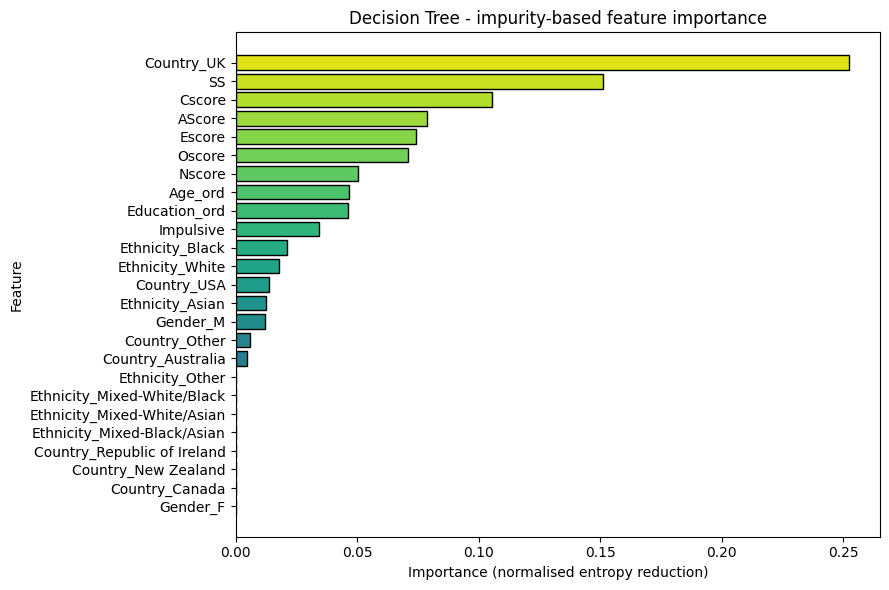

In [22]:
# Tree-based feature importance
feature_names = list(X.columns)

print('Decision Tree - feature importances:')
for name, imp in sorted(zip(feature_names, dectree.feature_importances_), key=lambda t: -t[1]):
    print('  %-25s : %.4f' % (name, imp))

plot_importance_bars(
    feature_names, dectree.feature_importances_,
    title='Decision Tree - impurity-based feature importance',
    xlabel='Importance (normalised entropy reduction)',
    cmap_name='viridis')

kNN - permutation importances:
  Age_ord                   : 0.0345
  SS                        : 0.0330
  Education_ord             : 0.0261
  Oscore                    : 0.0177
  Cscore                    : 0.0122
  Impulsive                 : 0.0106
  Ethnicity_White           : 0.0086
  AScore                    : 0.0078
  Nscore                    : 0.0077
  Ethnicity_Asian           : 0.0062
  Escore                    : 0.0046
  Ethnicity_Black           : 0.0042
  Gender_F                  : 0.0032
  Gender_M                  : 0.0032
  Country_UK                : 0.0031
  Country_USA               : 0.0021
  Country_Australia         : 0.0021
  Country_New Zealand       : 0.0000
  Ethnicity_Mixed-Black/Asian : 0.0000
  Ethnicity_Other           : -0.0002
  Ethnicity_Mixed-White/Black : -0.0006
  Country_Republic of Ireland : -0.0013
  Ethnicity_Mixed-White/Asian : -0.0013
  Country_Other             : -0.0013
  Country_Canada            : -0.0024


C:\Users\danie\AppData\Local\Temp\ipykernel_15688\2243425635.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.15, 0.95, len(names_sorted)))


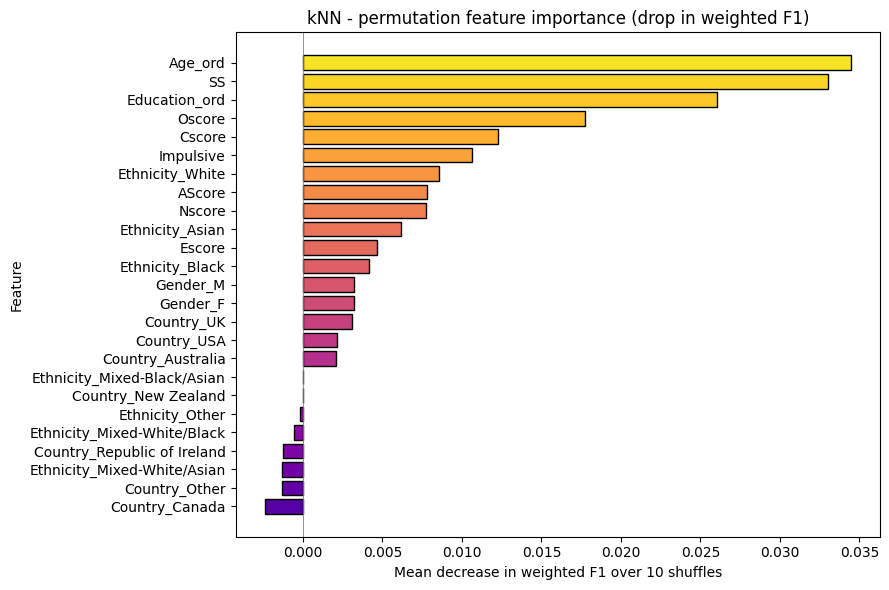

In [23]:
# kNN - permutation feature importance
from sklearn.inspection import permutation_importance

knn.fit(X_scaled, y)
perm = permutation_importance(knn, X_scaled, y,
                              n_repeats=10, scoring='f1_weighted', random_state=42)

print('kNN - permutation importances:')
for name, imp in sorted(zip(feature_names, perm.importances_mean), key=lambda t: -t[1]):
    print('  %-25s : %.4f' % (name, imp))

plot_importance_bars(
    feature_names, perm.importances_mean,
    title='kNN - permutation feature importance (drop in weighted F1)',
    xlabel='Mean decrease in weighted F1 over 10 shuffles',
    cmap_name='plasma')

---
## 10. Predictions on New Data

Both classifiers are applied to two hypothetical respondents that test the hypothesis explicitly:

- **Respondent A**: *young + high-risk personality profile*: aged 18–24, university-educated, female, UK, white, with high Sensation Seeking and Openness | Expected prediction: *user*.
- **Respondent B**: *older + low-risk personality profile*: aged 55–64, doctorate, male, USA, white, with low Sensation Seeking and Openness | Expected prediction: *non-user*.

In [24]:
# Generate respondents:

# Construct Respondent A:
respondent_A = pd.DataFrame(0, index=[0], columns=X.columns)
# personality scores
respondent_A['Nscore']        =  0.5
respondent_A['Escore']        =  0.0
respondent_A['Oscore']        =  1.8
respondent_A['AScore']        =  0.0
respondent_A['Cscore']        = -0.2
respondent_A['Impulsive']     =  1.2
respondent_A['SS']            =  1.5
# demographic variables
respondent_A['Age_ord']       = age_mapping['18-24']
respondent_A['Education_ord'] = education_mapping['Some college or university, no certificate or degree']
for col in ['Gender_F', 'Country_UK', 'Ethnicity_White']:
    if col in respondent_A.columns:
        respondent_A[col] = 1

# Construct Respondent B
respondent_B = pd.DataFrame(0, index=[0], columns=X.columns)
# personality scores
respondent_B['Nscore']        = -0.5
respondent_B['Escore']        =  0.0
respondent_B['Oscore']        = -1.0
respondent_B['AScore']        =  0.5
respondent_B['Cscore']        =  0.8
respondent_B['Impulsive']     = -1.0
respondent_B['SS']            = -1.5
# demographic variables
respondent_B['Age_ord']       = age_mapping['55-64']
respondent_B['Education_ord'] = education_mapping['Doctorate degree']
for col in ['Gender_M', 'Country_USA', 'Ethnicity_White']:
    if col in respondent_B.columns:
        respondent_B[col] = 1

print('Respondent A - personality scores (z-scores):')
print(respondent_A[personality_scores].to_string(index=False))
print()
print('Respondent B - personality scores (z-scores):')
print(respondent_B[personality_scores].to_string(index=False))

Respondent A - personality scores (z-scores):
 Nscore  Escore  Oscore  AScore  Cscore  Impulsive  SS
    0.5     0.0     1.8     0.0    -0.2        1.2 1.5

Respondent B - personality scores (z-scores):
 Nscore  Escore  Oscore  AScore  Cscore  Impulsive   SS
   -0.5     0.0    -1.0     0.5     0.8       -1.0 -1.5


In [25]:
# Predict with both classifiers and display structured results
respondent_A_scaled = scaler.transform(respondent_A)
respondent_B_scaled = scaler.transform(respondent_B)

names    = ['Respondent A', 'Respondent B']
expected = ['User',         'Non-user'    ]

print('Decision Tree (depth=%d):' % best_depth)
for name, row, exp in zip(names, [respondent_A, respondent_B], expected):
    pred  = dectree.predict(row)[0]
    prob  = dectree.predict_proba(row)[0]
    label = 'User' if pred == 1 else 'Non-user'
    note  = '' if label == exp else '  - expected: %s' % exp
    print('  %-14s : %-8s  P(non-user)=%.3f  P(user)=%.3f%s' % (name, label, prob[0], prob[1], note))

print()
print('kNN (k=%d):' % best_k)
for name, row, exp in zip(names, [respondent_A_scaled, respondent_B_scaled], expected):
    pred  = knn.predict(row)[0]
    prob  = knn.predict_proba(row)[0]
    label = 'User' if pred == 1 else 'Non-user'
    note  = '' if label == exp else '  - expected: %s' % exp
    print('  %-14s : %-8s  P(non-user)=%.3f  P(user)=%.3f%s' % (name, label, prob[0], prob[1], note))

Decision Tree (depth=8):
  Respondent A   : User      P(non-user)=0.000  P(user)=1.000
  Respondent B   : User      P(non-user)=0.000  P(user)=1.000  - expected: Non-user

kNN (k=7):
  Respondent A   : User      P(non-user)=0.143  P(user)=0.857
  Respondent B   : User      P(non-user)=0.000  P(user)=1.000  - expected: Non-user


### 10.2 Diagnostic: Why is Respondent B classified as User?

Both classifiers predict Respondent B (older, low SS, low Openness, doctorate) as a Cannabis user. This is unexpected given the EDA hypothesis. Two complementary diagnostics explain the result and reveal a real limitation of the model.

In [35]:
# Diagnostic 1: examine the 7 nearest neighbours of Respondent B in the scaled feature space
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=best_k, metric='euclidean')
nn_model.fit(X_scaled)

distances, indices = nn_model.kneighbors(respondent_B_scaled)

print('The %d nearest neighbours of Respondent B in the training data:' % best_k)
print()
print('%-8s %-10s %-12s %-10s %-8s %-8s %-8s' %
      ('Index', 'Distance', 'Cannabis', 'Age', 'Gender', 'SS', 'Oscore'))
print('-' * 70)

neighbour_labels = []
for d, i in zip(distances[0], indices[0]):
    cannabis_val = myData.iloc[i]['Cannabis']
    label = 'User' if cannabis_val != 'CL0' else 'Non-user'
    neighbour_labels.append(label)
    print('%-8d %-10.4f %-12s %-10s %-8s %-8.2f %-8.2f' %
          (i, d, label, myData.iloc[i]['Age'], myData.iloc[i]['Gender'],
           myData.iloc[i]['SS'], myData.iloc[i]['Oscore']))

n_users     = neighbour_labels.count('User')
n_non_users = neighbour_labels.count('Non-user')
print()
print('Vote: %d User vs %d Non-user -> predicted class: %s'
      % (n_users, n_non_users, 'User' if n_users > n_non_users else 'Non-user'))

The 7 nearest neighbours of Respondent B in the training data:

Index    Distance   Cannabis     Age        Gender   SS       Oscore  
----------------------------------------------------------------------
952      0.4010     User         45-54      M        -0.85    -0.58   
1231     0.4017     User         55-64      M        -0.85    0.58    
1006     0.5269     User         45-54      M        -0.53    -0.02   
5        0.5308     User         45-54      M        0.08     -0.45   
714      0.5387     User         35-44      M        -0.85    -0.32   
972      0.5707     User         65+        M        -0.53    0.58    
1841     0.6045     User         45-54      M        0.08     0.58    

Vote: 7 User vs 0 Non-user -> predicted class: User


The neighbour table shows the root cause: even the *closest* respondents in feature space to a low-risk profile are mostly Cannabis users, because users make up 76% of the dataset. The 24% non-user minority is too sparse for kNN to find a non-user neighbourhood around any reasonable point.

In [36]:
# Diagnostic 2: class-conditional means of the top features show the small effect size
top_features = ['SS', 'Oscore', 'Age_ord', 'Cscore']

print('Class-conditional means of the top features:')
print()
print('%-12s %-15s %-15s %-12s' % ('Feature', 'Non-users mean', 'Users mean', 'Difference'))
print('-' * 58)
for feat in top_features:
    mean_nonuser = X.loc[y == 0, feat].mean()
    mean_user    = X.loc[y == 1, feat].mean()
    diff         = mean_user - mean_nonuser
    print('%-12s %-15.3f %-15.3f %+.3f' % (feat, mean_nonuser, mean_user, diff))

Class-conditional means of the top features:

Feature      Non-users mean  Users mean      Difference  
----------------------------------------------------------
SS           -0.652          0.179           +0.831
Oscore       -0.579          0.162           +0.741
Age_ord      1.981           1.168           -0.813
Cscore       0.451           -0.127          -0.577


The class-conditional differences in personality scores are real but modest typically 0.3 to 0.7 standard deviations. This is enough for a classifier to learn a tendency, but not enough to override the strong 76/24 class prior for borderline cases.

---
## 11. Summary of Key Findings

1. **kNN outperforms the majority-class baseline; the Decision Tree only marginally.** A trivial classifier predicting *user* always reaches 78.1% accuracy. kNN at 80.4% is a real improvement; the Decision Tree at 77.1% sits within one standard deviation of the baseline.

2. **Feature importance partially confirms the EDA hypothesis.** kNN ranks Sensation Seeking, Age and Openness as the top three predictors, exactly the features flagged by the EDA. The Decision Tree puts Country_UK first, which is most likely a shortcut for the local class prior (UK respondents are 55% of the sample). The convergence on Sensation Seeking across both methods is the most reliable signal.

3. **The Respondent-B test reveals a real limitation.** Both classifiers predict B as a user contrary to the EDA-derived expectation. The diagnostic shows the cause: even the seven nearest neighbours of B are mostly users, because the 76% class prior dominates. The models reliably identify users (recall 86–91%) but identify non-users much less well (recall 43–47%).

4. **Methodological honesty.** The dataset oversamples younger UK respondents. The class imbalance and moderate effect sizes place a ceiling on minority-class recall that cannot be overcome by classifier choice alone.